# Graph by using GOOGLE ANTIGRAVITY

--- Adjacency List ---
Node A (h=7) -> [(B, w=2), (C, w=4)]
Node B (h=6) -> [(C, w=1), (D, w=7)]
Node C (h=4) -> [(E, w=3)]
Node D (h=1) -> [(F, w=1)]
Node E (h=4) -> [(D, w=2), (F, w=5)]
Node F (h=0) -> []
----------------------

Graph visualization saved as 'graph_visualization.png'


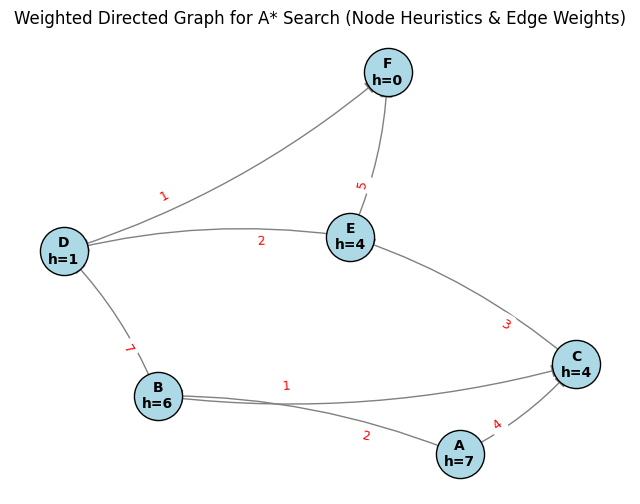

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def create_and_visualize_graph():
    # Define a directed graph
    G = nx.DiGraph()

    # Define heuristics for each node (e.g., estimated distance to goal 'F')
    heuristics = {
        'A': 7,
        'B': 6,
        'C': 4,
        'D': 1,
        'E': 4,
        'F': 0
    }

    # Add nodes with their heuristic values
    for node, h in heuristics.items():
        G.add_node(node, heuristic=h)

    # Define edges with weights
    edges = [
        ('A', 'B', 2),
        ('A', 'C', 4),
        ('B', 'C', 1),
        ('B', 'D', 7),
        ('C', 'E', 3),
        ('D', 'F', 1),
        ('E', 'D', 2),
        ('E', 'F', 5)
    ]

    # Add edges to the graph
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    # Print adjacency list
    print("--- Adjacency List ---")
    for node in G.nodes():
        neighbors = G[node]
        adj_str = ", ".join([f"({neighbor}, w={data['weight']})" for neighbor, data in neighbors.items()])
        h_val = G.nodes[node]['heuristic']
        print(f"Node {node} (h={h_val}) -> [{adj_str}]")
    print("----------------------\n")

    # Visualization
    # Use a fixed seed for spring layout to get consistent visualizations
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(8, 6))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', edgecolors='black')

    # Draw node labels (incorporating node name and heuristic value)
    labels = {node: f"{node}\nh={G.nodes[node]['heuristic']}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', connectionstyle='arc3,rad=0.1')

    # Draw edge weight labels
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, label_pos=0.3, font_size=9, font_color='red')

    plt.title("Weighted Directed Graph for A* Search (Node Heuristics & Edge Weights)")
    plt.axis('off') # Hide axes

    # Save the plot
    output_image = "graph_visualization.png"
    plt.savefig(output_image, bbox_inches='tight')
    print(f"Graph visualization saved as '{output_image}'")

if __name__ == '__main__':
    create_and_visualize_graph()
